In [16]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

# Allow importing the package from the repo root
sys.path.insert(0, str(Path(".").resolve().parent))

from qaoa_parameter_setting.utils.database.results_database import ResultsDatabase

import figure_styles

In [17]:
# ── constants ────────────────────────────────────────────────────────────────
NUM_FILES  = 10         
DATA_DIR   = "../data/training/random_regular"
OUTPUT_FILE = "figure_6.pdf"

DEPTHS = [2, 4, 6, 8]


PP_MAX_WEIGHT = {"MIS": 5, "MC": 4}

METHOD_LEGEND_TITLE = "Parameter setting method"

PP_METHOD_LABELS = [
    "TQA*",
    "Fixed Angles*",
    "Interp.*",
    "Fourier*",
]

In [18]:
# ── Load data via ResultsDatabase ────────────────────────────────────────────

warnings.simplefilter("ignore")

db_mis = ResultsDatabase(problem_class="MIS", num_nodes=[40])
db_mis.add_data(DATA_DIR)

db_mc = ResultsDatabase(problem_class="MC", num_nodes=[40])
db_mc.add_data(DATA_DIR)


def _best_df_pp(db, problem_class, graph_type_filter):
    """One best PP result per (instance, method_label, depth) at the correct weight.
    """
    weight = PP_MAX_WEIGHT[problem_class]
    df = db.to_dataframe().pipe(lambda d: d[
        (d["evaluation"] == "PP")
        & d["instance"].str.contains(graph_type_filter)
        & (d["pp_max_weight"] == weight)
        & d["method_label"].isin(PP_METHOD_LABELS)
    ]).copy()
    df["_src_depth"] = (
        df["source_file"]
        .str.extract(r'_(\d+)\.json$', expand=False)
        .astype(int)
    )
    df = (
        df
        .sort_values(
            ["_src_depth", "run_datetime", "energy"],
            ascending=[False, False, False],
        )
        .drop_duplicates(subset=["instance", "method_label", "depth"])
        .drop(columns=["_src_depth"])
    )
    return df


df_mis = _best_df_pp(db_mis, "MIS", "random3regular")
df_mc  = _best_df_pp(db_mc,  "MC",  "random3regular")

print(f"Rows loaded — PP: MIS={len(df_mis)}, MC={len(df_mc)}")

Rows loaded — PP: MIS=230, MC=280


In [19]:
# ── Coverage report ──────────────────────────────────────────────────────────

def report_coverage(label, df, method_labels, depths):
    print(f"[{label}]")
    sub = df[df["method_label"].isin(method_labels) & df["depth"].isin(depths)]
    stats = (
        sub.groupby(["method_label", "depth"])["instance"]
        .count()
        .reset_index(name="n")
    )
    for _, row in stats.iterrows():
        flag = " *** BELOW TARGET ***" if row["n"] < NUM_FILES else ""
        print(
            f"  method={row['method_label']!r:20s}  depth={row['depth']:2d}  "
            f"n={row['n']}/{NUM_FILES}{flag}"
        )


report_coverage("MIS PP (axs[0])", df_mis, PP_METHOD_LABELS, DEPTHS)
print()
report_coverage("MC  PP (axs[1])", df_mc,  PP_METHOD_LABELS, DEPTHS)

[MIS PP (axs[0])]
  method='Fixed Angles*'       depth= 2  n=10/10
  method='Fixed Angles*'       depth= 4  n=10/10
  method='Fixed Angles*'       depth= 6  n=10/10
  method='Fixed Angles*'       depth= 8  n=10/10
  method='Fourier*'            depth= 2  n=10/10
  method='Fourier*'            depth= 4  n=10/10
  method='Fourier*'            depth= 6  n=10/10
  method='Fourier*'            depth= 8  n=10/10
  method='Interp.*'            depth= 2  n=10/10
  method='Interp.*'            depth= 4  n=10/10
  method='Interp.*'            depth= 6  n=10/10
  method='Interp.*'            depth= 8  n=10/10
  method='TQA*'                depth= 2  n=10/10
  method='TQA*'                depth= 4  n=10/10
  method='TQA*'                depth= 6  n=10/10
  method='TQA*'                depth= 8  n=10/10

[MC  PP (axs[1])]
  method='Fixed Angles*'       depth= 2  n=10/10
  method='Fixed Angles*'       depth= 4  n=10/10
  method='Fixed Angles*'       depth= 6  n=10/10
  method='Fixed Angles*'       d

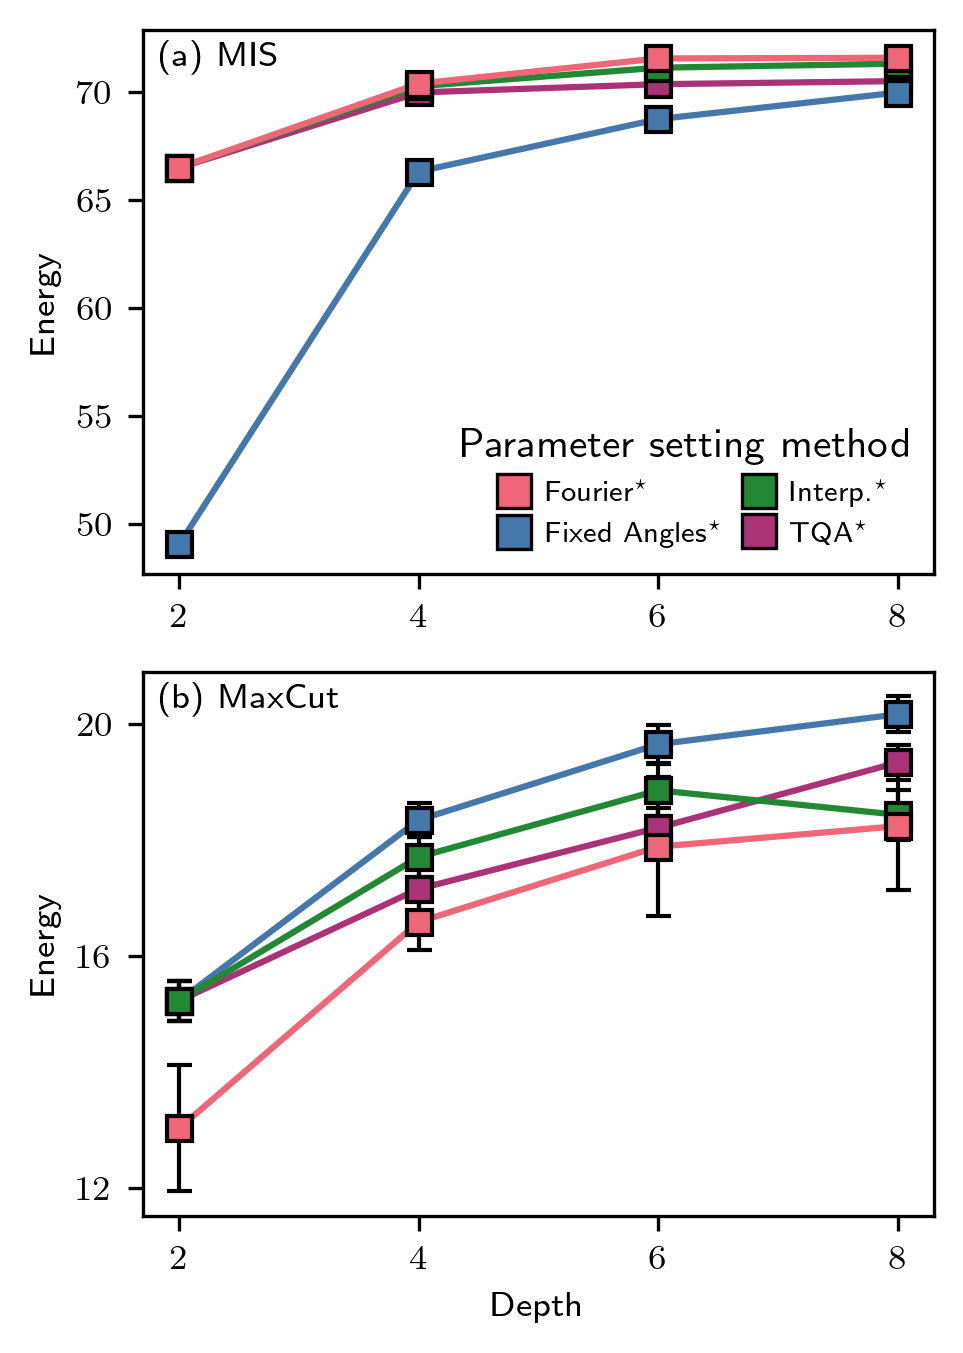

In [20]:
# ── Plot ─────────────────────────────────────────────────────────────────────

figure_styles.apply_rcparams()
layout = figure_styles.construct_plot(2, 1, aspect_ratio=0.8)

for ax, df in zip(layout.flat_axes(), [df_mis, df_mc]):
    sub = df[df["method_label"].isin(PP_METHOD_LABELS) & df["depth"].isin(DEPTHS)]
    for method_label in PP_METHOD_LABELS:
        rows = sub[sub["method_label"] == method_label]
        if rows.empty:
            continue
        stats = (
            rows.groupby("depth")["energy"]
            .agg(mean="mean", std="std")
            .reset_index()
            .sort_values("depth")
        )
        ax.errorbar(
            stats["depth"].to_numpy(),
            stats["mean"].to_numpy(),
            yerr=stats["std"].to_numpy(),
            label=figure_styles.format_method_label(method_label),
            **figure_styles.style_errorbar(method_label, "PP"),
        )
    ax.set_xticks(DEPTHS)

layout.axs[1][0].set_xlabel("Depth")
layout.axs[0][0].set_ylabel("Energy")
layout.axs[1][0].set_ylabel("Energy")
layout.axs[1][0].set_yticks([12, 16, 20])

# ── legend ───────────────────────────────────────────────────────────────────

method_legend_items = [
    ("Fourier",       "Fourier"),
    ("Fixed Angles*", "Fixed Angles*"),
    ("INTERP",        "INTERP"),
    ("TQA*",          "TQA*"),
]
method_handles = [
    figure_styles.method_legend_handle(
        figure_styles.format_method_label(label), method
    )
    for label, method in method_legend_items
]
layout.axs[0][0].legend(handles=method_handles, title=METHOD_LEGEND_TITLE,loc="lower right",bbox_to_anchor=(1, 0.01),
    **{k: v for k, v in layout.method_legend_kw.items() if k not in ("loc", "bbox_to_anchor")},)

figure_styles.add_panel_labels(layout.flat_axes(), labels=("(a) MIS", "(b) MaxCut"))
layout.apply_subplots_adjust(bottom=-0.05, wspace=0)

layout.fig.savefig(OUTPUT_FILE, **figure_styles.savefig_kwargs())
layout.fig.show()